# 1. Thiết lập và load dữ liệu

Khởi tạo môi trường thực nghiệm và load dataset Zoo.

Thực hiện:

* Thiết lập seed để đảm bảo reproducibility
* Load đặc trưng và nhãn từ dataset
* Chuẩn hóa format dữ liệu về NumPy array


In [1]:
from pathlib import Path
import importlib
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent
SRC_DIR = ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import utils as src_utils
src_utils = importlib.reload(src_utils)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = ROOT / "data"
ZOO_PATH = DATA_DIR / "zoo" / "zoo.csv"

# 2. Xây dựng pipeline học từ triplets

Thiết lập các thành phần chính của pipeline:

* Sinh triplets từ dữ liệu gốc (cosine-based)
* Tính similarity matrix từ triplets
* Áp dụng hierarchical clustering (Average Linkage)
* Đánh giá bằng Revenue và AARI


In [2]:
# Load dataset 
X, y = src_utils.load_zoo_features(ZOO_PATH)
X, y = np.asarray(X), np.asarray(y).reshape(-1)
n = len(X)

print(f"Dataset loaded: Zoo | n = {n}")

# ================= ALIASES =================
build_triplets = src_utils.build_cosine_triplets
adds3_sim = src_utils.compute_adds3_similarity
naive_sim = src_utils.naive_similarity
linkage = src_utils.average_linkage_from_similarity
revenue_fn = src_utils.triplet_revenue
aari_fn = src_utils.compute_aari


Dataset loaded: Zoo | n = 100


# 3. Ablation 1: So sánh hàm similarity

So sánh hai cách xây dựng similarity:

* AddS3: phương pháp đề xuất trong bài
* Naive: cách đếm đơn giản từ triplets

Giữ cố định:

* k_factor
* noise_rate

Đánh giá:

* Revenue
* AARI


In [3]:
T = build_triplets(X, k_factor=0.3, noise_rate=0.05, random_state=SEED)

# AddS3
S_adds3 = adds3_sim(n, T)
Z_adds3 = linkage(S_adds3)

# Naive
S_naive = naive_sim(n, T)
Z_naive = linkage(S_naive)

df_ablation1 = pd.DataFrame([
    {
        "Method": "AddS3",
        "Revenue": revenue_fn(Z_adds3, T),
        "AARI": aari_fn(Z_adds3, y)
    },
    {
        "Method": "Naive",
        "Revenue": revenue_fn(Z_naive, T),
        "AARI": aari_fn(Z_naive, y)
    },
])

display(df_ablation1)


,Method,Revenue,AARI
0,AddS3,68934.0,0.357927
1,Naive,51559.0,0.205845


# 4. Ablation 2: Ảnh hưởng của nhiễu (noise)

Thay đổi mức noise trong quá trình sinh triplets:

* Không nhiễu (0.0)
* Có nhiễu nhẹ (0.05)

Giữ cố định:

* k_factor
* phương pháp AddS3

Đánh giá:

* Revenue
* AARI

In [4]:
noise_levels = np.arange(0.0, 0.51, 0.05)  # Quet tu 0% den 50% nhieu (buoc nhay 5%)
rows = []
for noise in noise_levels:
    T = build_triplets(X, k_factor=0.3, noise_rate=noise, random_state=SEED)

    S = adds3_sim(n, T)
    Z = linkage(S)

    rows.append({
        "Noise": noise,
        "Revenue": revenue_fn(Z, T),
        "AARI": aari_fn(Z, y)
    })

df_ablation2 = pd.DataFrame(rows)
display(df_ablation2)

,Noise,Revenue,AARI
0,0.00,71428.0,0.344386
1,0.05,68934.0,0.357927
2,0.10,60686.0,0.336821
3,0.15,55272.0,0.400925
4,0.20,42307.0,0.099643
5,0.25,37057.0,0.121007
6,0.30,32467.0,0.066760
7,0.35,30639.0,0.011372
8,0.40,31197.0,0.011413
9,0.45,32861.0,0.000233


# 5. Ablation 3: Ảnh hưởng của số lượng triplets

Thay đổi số lượng triplets thông qua k_factor:

* k nhỏ → ít dữ liệu
* k lớn → nhiều dữ liệu

Giữ cố định:

* noise_rate
* phương pháp AddS3

Đánh giá:

* Revenue
* AARI

,k_factor,Revenue,AARI
0,0.05,15008.0,0.083120
1,0.10,25533.0,0.173416
2,0.20,44828.0,0.290991
3,0.40,91923.0,0.338732
4,0.60,148452.0,0.383603
5,0.80,197985.0,0.433503
6,1.00,253932.0,0.527636
7,1.50,391095.0,0.530208
8,2.00,523199.0,0.469501


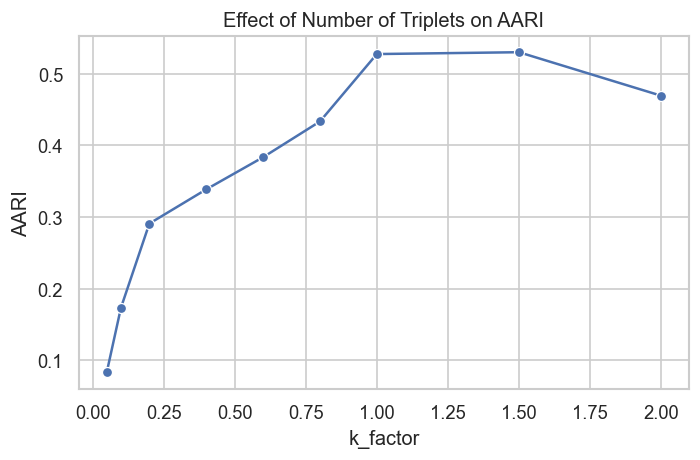

In [5]:
k_factors = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]  # Quet tu rat it den rat nhieu data

rows = []
for kf in k_factors:
    T = build_triplets(X, k_factor=kf, noise_rate=0.05, random_state=SEED)

    S = adds3_sim(n, T)
    Z = linkage(S)

    rows.append({
        "k_factor": kf,
        "Revenue": revenue_fn(Z, T),
        "AARI": aari_fn(Z, y)
    })

df_ablation3 = pd.DataFrame(rows)
display(df_ablation3)

# ================= VISUALIZATION =================
plt.figure(figsize=(6, 4))
sns.lineplot(data=df_ablation3, x="k_factor", y="AARI", marker="o")
plt.title("Effect of Number of Triplets on AARI")
plt.xlabel("k_factor")
plt.ylabel("AARI")
plt.tight_layout()
plt.show()